# Some issues, strange places, and suggestions in `TensorFlow`'s official document "Introduction to graphs and tf.function"

I've learnt a lot of `TensorFlow` from the official documentation. I appreciate the official documents helping me solve many problems in my project.

There are some issues and strange places when I am reading the official document "[Introduction to graphs and tf.function](https://www.tensorflow.org/guide/intro_to_graphs)".

This is a brief issue report. I wish we could make the document better and benefit readers / researchers / engineers.


Date: 2026-04-09

## 1. Setup

In [1]:
import tensorflow as tf

2026-04-09 15:07:27.535674: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 15:07:27.775073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775718447.883212    8996 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775718447.925892    8996 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775718448.143990    8996 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 2. Issues, strange places, and suggestions

### 2.1. Better example code for the "Taking advantage of graphs" section

**Position:**  
"Taking advantage of graphs" section

**Link:**  
https://www.tensorflow.org/guide/intro_to_graphs#taking_advantage_of_graphs

**Condition:**  
The example code is OK, no bug. I am talking about a more detailed consideration about the tutorial.

In the last line of the example code, the `assert` keyword is used to check the values between `a_regular_function()` and `tf.function(a_regular_function)`.
```Python
assert(orig_value == tf_function_value)
```
However, when I run the code, nothing happens. As I learned the usage of `assert`, I understood that "noting happens" indicates "orig_value == tf_function_value". 

NOTE: In Python, the [`assert`](https://docs.python.org/3/reference/simple_stmts.html#grammar-token-python-grammar-assert_stmt) keyword is a debugging tool used to verify that a condition is true. If the condition evaluates to False, the program immediately raises an AssertionError and terminates, helping developers catch bugs during the development and testing phases.

**Suggestion:**  
In my opinion, a tutorial should give readers an "explicit" guide instead of an "implicit" guide. Using `print` is a better choice than using `assert`.

When using `print`, a `True` or `False` will be sent according to the conditional expression `orig_value == tf_function_value`, and readers will understand the result explicitly and immediately.
```Python
print(orig_value == tf_function_value)
```

A suggested example code is given below.

**What I have learned in this example:**  
Through the tutorial, I understand that  
1. `tf.function` takes a regular function as input and returns a `tf.types.experimental.PolymorphicFunction`. 
2. A `PolymorphicFunction` is a Python callable that builds TensorFlow graphs from the Python function.
3. I use a `tf.function` in the same way as its Python equivalent.

The suggested example code:

In [2]:
# Define a Python function.
def a_regular_function(x, y, b):
    x = tf.matmul(x, y)
    x = x + b
    return x

# The Python type of `a_function_that_uses_a_graph` will now be a
# `PolymorphicFunction`.
a_function_that_uses_a_graph = tf.function(a_regular_function)

# Make some tensors.
x1 = tf.constant([[1.0, 2.0]])
y1 = tf.constant([[2.0], [3.0]])
b1 = tf.constant(4.0)

orig_value = a_regular_function(x1, y1, b1).numpy()
# Call a `tf.function` like a Python function.
tf_function_value = a_function_that_uses_a_graph(x1, y1, b1).numpy()
print(orig_value == tf_function_value)

[[ True]]


I0000 00:00:1775718529.727067    8996 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 673 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Test suggested example code with `print(orig_value != tf_function_value)`:

In [3]:
print(orig_value != tf_function_value)

[[False]]


Original example code:  
(Screenshot date: 2026-04-09)  

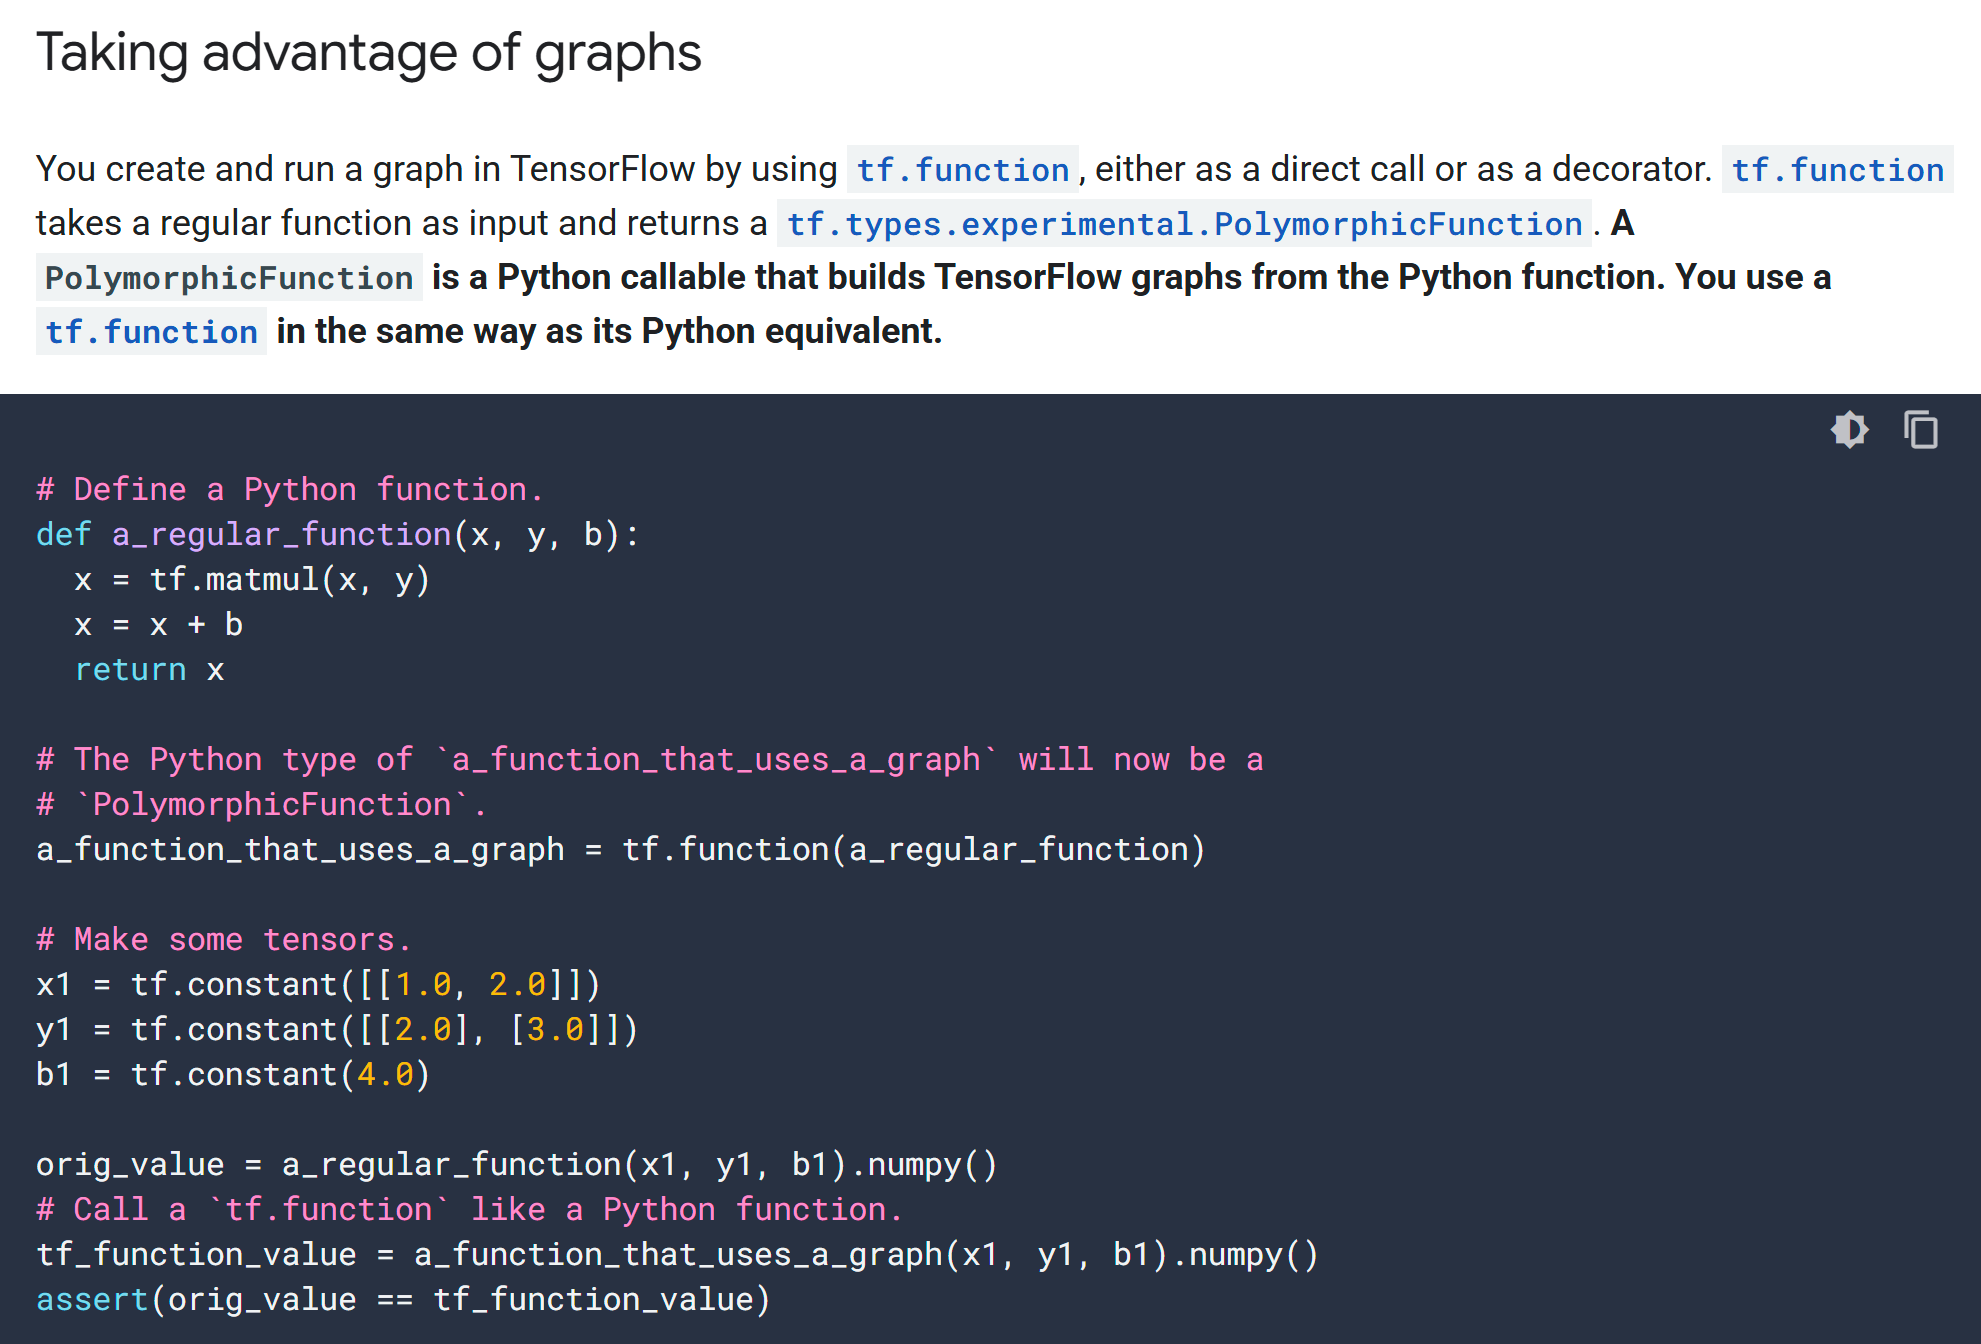

### 2.2. Content format corrections

It seems that the markdown symbols "_" are outside the target words.

Strange sentence 1:  
"...and you can learn more about it in the \_Speeding-up your training step with tf.function\_ section..."  
It might be  
"...and you can learn more about it in the _Speeding-up your training step with tf.function_ section..."  

Strange sentence 2:  
"Learn more in the _Explicit compilation with tf.function(jitcompile=True) section..."  
It might be  
"Learn more in the _Explicit compilation with tf.function(jitcompile=True)_ section..."  

Original content on the Tensorflow offical website  
Screenshot date: 2026-04-09  
from https://www.tensorflow.org/guide/intro_to_graphs
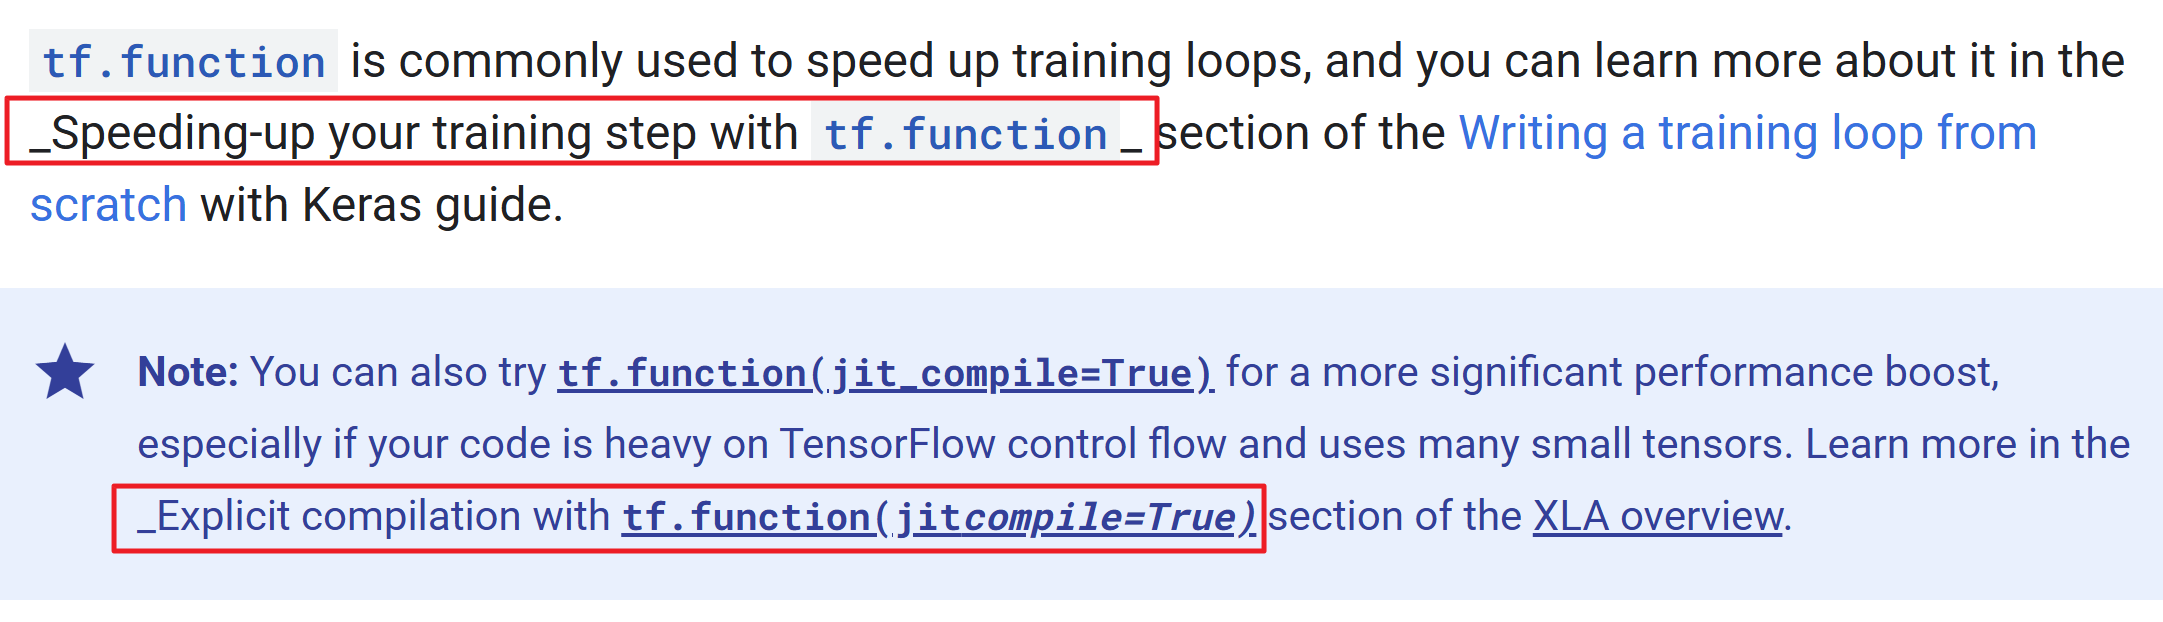

Before I send the issue report to the https://github.com/tensorflow/docs , I found the content in the doc on GitHub is right. It might just be a display issue on the website.

Screenshot date: 2026-04-09  
from https://github.com/tensorflow/docs/blob/master/site/en/guide/intro_to_graphs.ipynb
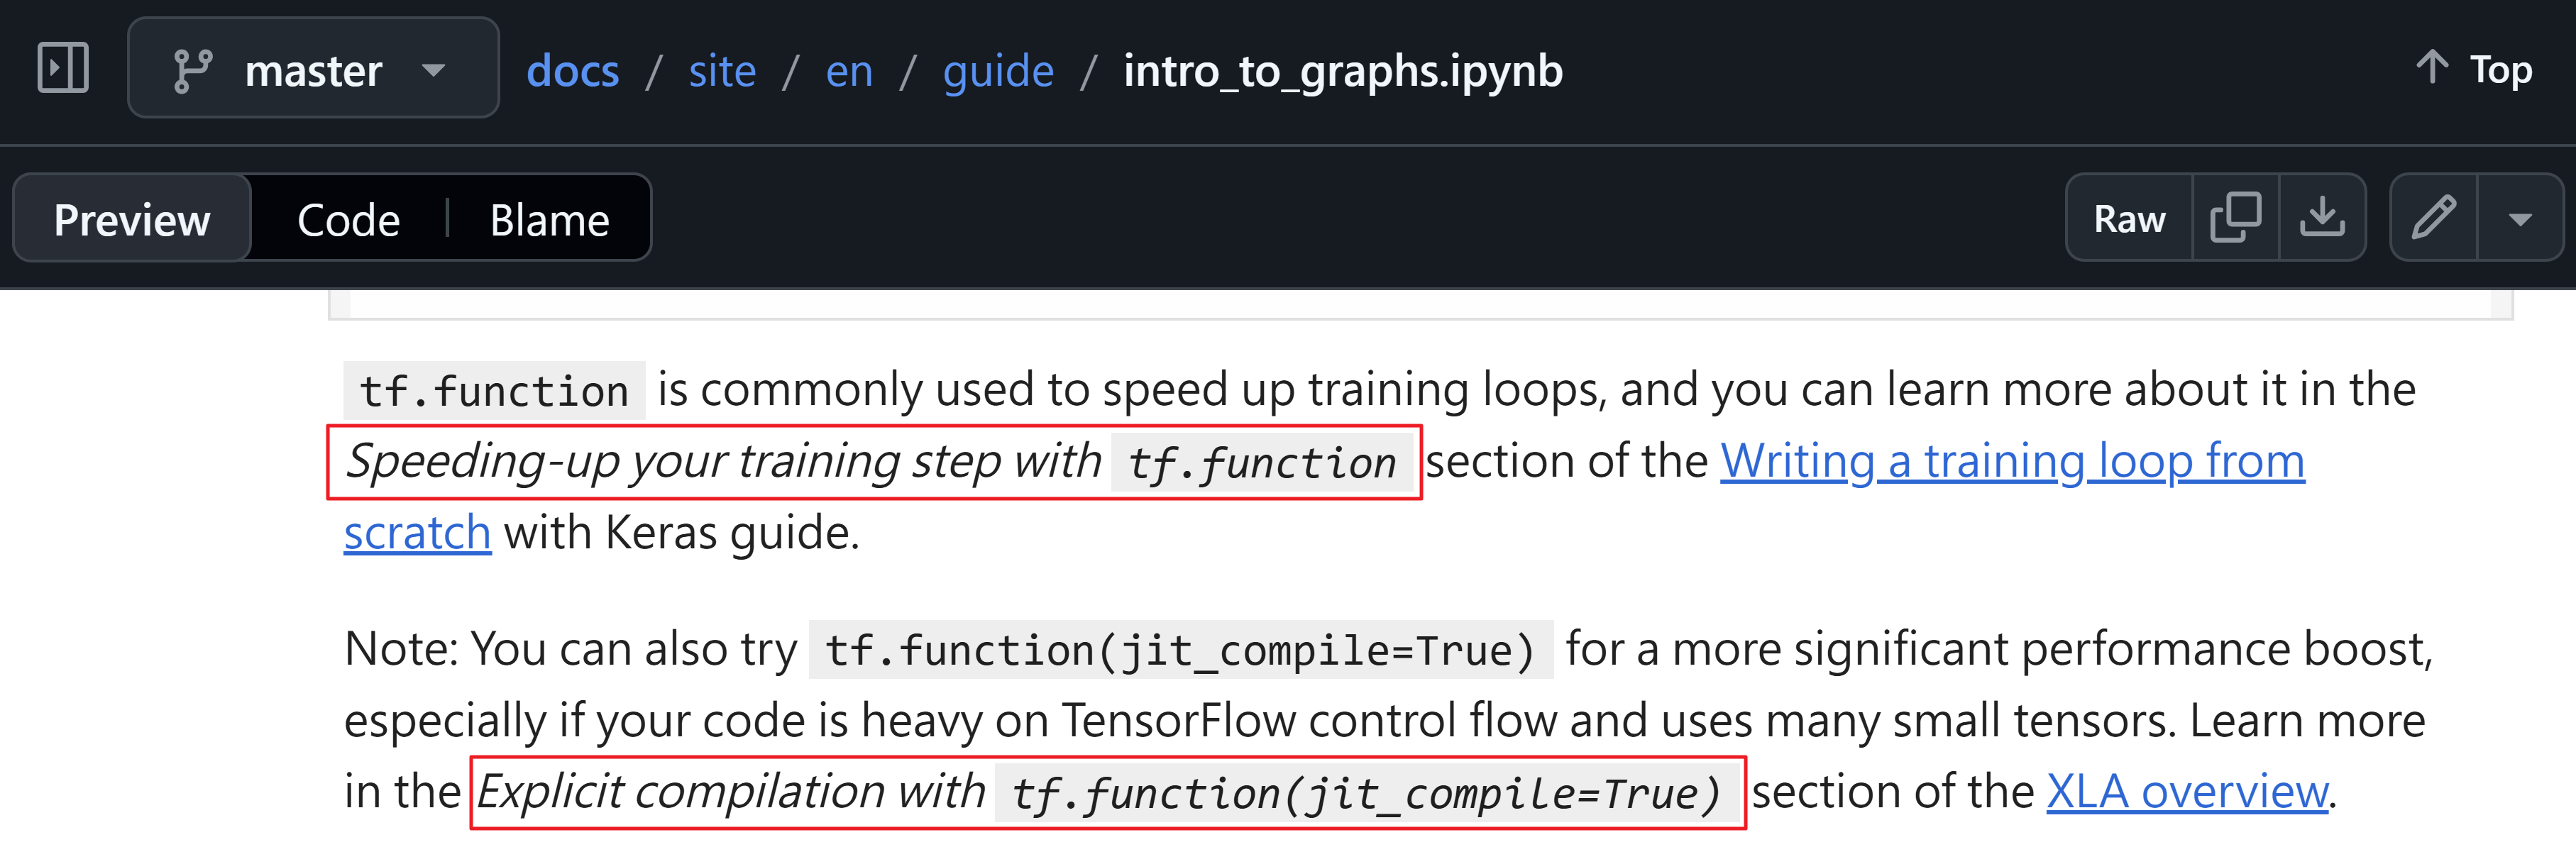